In [1]:
import pandas as pd

data = pd.read_csv("data.csv")
data.head()

,material_cost,labor_hours,product_type,customer_type,season,price,demand
0,120,2,keychain,budget,normal,300,Low
1,150,3,keychain,budget,festival,450,Medium
2,200,4,photo_frame,mid,normal,700,Medium
3,300,6,photo_frame,mid,festival,1000,High
4,500,10,jewellery,premium,festival,1800,High


In [2]:
data.dropna()

,material_cost,labor_hours,product_type,customer_type,season,price,demand
0,120,2,keychain,budget,normal,300,Low
1,150,3,keychain,budget,festival,450,Medium
2,200,4,photo_frame,mid,normal,700,Medium
3,300,6,photo_frame,mid,festival,1000,High
4,500,10,jewellery,premium,festival,1800,High
5,450,9,jewellery,premium,normal,1500,Medium
6,250,5,decor,mid,festival,900,High
7,200,4,decor,budget,normal,600,Medium
8,100,2,keychain,budget,normal,250,Low
9,130,3,keychain,budget,festival,400,Medium


In [5]:

data = pd.get_dummies(data)

data.head()

,material_cost,labor_hours,price,product_type_decor,product_type_jewellery,product_type_keychain,product_type_photo_frame,customer_type_budget,customer_type_mid,customer_type_premium,season_festival,season_normal,demand_High,demand_Low,demand_Medium
0,120,2,300,False,False,True,False,True,False,False,False,True,False,True,False
1,150,3,450,False,False,True,False,True,False,False,True,False,False,False,True
2,200,4,700,False,False,False,True,False,True,False,False,True,False,False,True
3,300,6,1000,False,False,False,True,False,True,False,True,False,True,False,False
4,500,10,1800,False,True,False,False,False,False,True,True,False,True,False,False


In [9]:
X = data.drop(['price','demand_High','demand_Low','demand_Medium'], axis=1)

y_price = data['price']
y_demand = data['demand_High']

In [8]:
print(data.columns)


Index(['material_cost', 'labor_hours', 'price', 'product_type_decor',
       'product_type_jewellery', 'product_type_keychain',
       'product_type_photo_frame', 'customer_type_budget', 'customer_type_mid',
       'customer_type_premium', 'season_festival', 'season_normal',
       'demand_High', 'demand_Low', 'demand_Medium'],
      dtype='object')


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_price_train, y_price_test = train_test_split(X, y_price, test_size=0.2)

_, _, y_demand_train, y_demand_test = train_test_split(X, y_demand, test_size=0.2)

In [11]:
from sklearn.ensemble import RandomForestRegressor

price_model = RandomForestRegressor()
price_model.fit(X_train, y_price_train)

RandomForestRegressor()

In [12]:
from sklearn.ensemble import RandomForestClassifier

demand_model = RandomForestClassifier()
demand_model.fit(X_train, y_demand_train)

RandomForestClassifier()

In [16]:

demand_pred = demand_model.predict(X_test)


from sklearn.metrics import accuracy_score

acc = accuracy_score(y_demand_test, demand_pred)
print("Demand Model Accuracy:", acc)

Demand Model Accuracy: 0.5


In [17]:
from joblib import dump

dump(price_model, 'price_model.joblib')
dump(demand_model, 'demand_model.joblib')

['demand_model.joblib']

In [18]:
from joblib import load

price_model = load('price_model.joblib')
demand_model = load('demand_model.joblib')

In [19]:
import pandas as pd

sample = pd.DataFrame([{
    'material_cost': 200,
    'labor_hours': 4,
    'product_type_decor': 1,
    'product_type_jewellery': 0,
    'product_type_keychain': 0,
    'product_type_photo_frame': 0,
    'customer_type_budget': 1,
    'customer_type_mid': 0,
    'customer_type_premium': 0,
    'season_festival': 0,
    'season_normal': 1
}])

price = price_model.predict(sample)
demand = demand_model.predict(sample)

print("Predicted Price:", price[0])
print("High Demand (1=Yes, 0=No):", demand[0])

Predicted Price: 604.3
High Demand (1=Yes, 0=No): False


In [20]:
if demand[0] == 1:
    print("Demand: High 🔥")
else:
    print("Demand: Not High")

Demand: Not High


In [21]:
profit = price[0] - 200
print("Profit:", profit)

Profit: 404.29999999999995


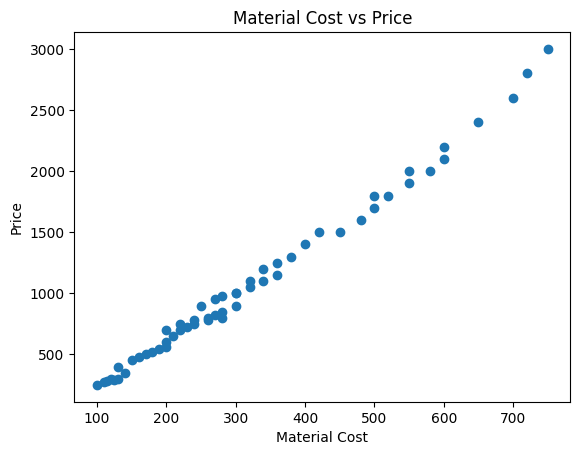

In [22]:
import matplotlib.pyplot as plt

plt.scatter(data['material_cost'], data['price'])
plt.xlabel("Material Cost")
plt.ylabel("Price")
plt.title("Material Cost vs Price")

plt.show()

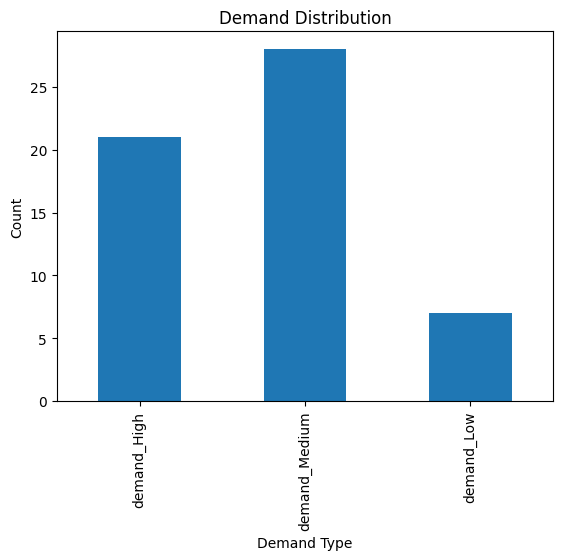

In [23]:
demand_counts = data[['demand_High','demand_Medium','demand_Low']].sum()

demand_counts.plot(kind='bar')

plt.title("Demand Distribution")
plt.xlabel("Demand Type")
plt.ylabel("Count")

plt.show()

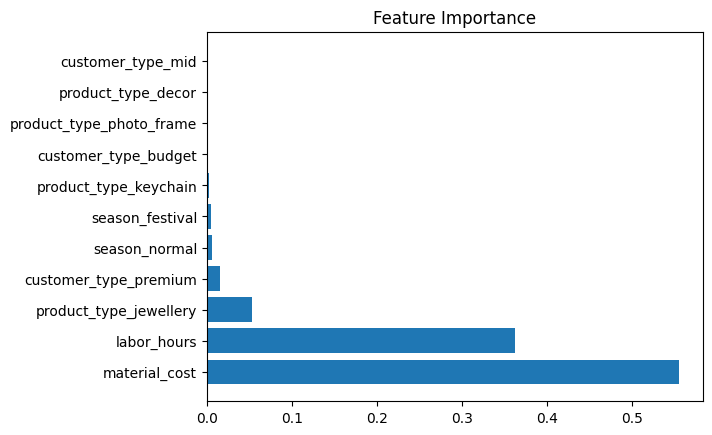

In [24]:
import pandas as pd

importance = price_model.feature_importances_
features = X.columns

imp_df = pd.DataFrame({'Feature': features, 'Importance': importance})
imp_df = imp_df.sort_values(by='Importance', ascending=False)

plt.barh(imp_df['Feature'], imp_df['Importance'])
plt.title("Feature Importance")

plt.show()

In [32]:
import pandas as pd

sample = pd.DataFrame([{
    'material_cost': 1000,
    'labor_hours': 2,
    'product_type_decor': 0,
    'product_type_jewellery': 0,
    'product_type_keychain': 5,
    'product_type_photo_frame': 1,
    'customer_type_budget': 500,
    'customer_type_mid': 0,
    'customer_type_premium': 0,
    'season_festival': 0,
    'season_normal': 1
}])

price = price_model.predict(sample)
demand = demand_model.predict(sample)

print("Predicted Price:", price[0])
print("High Demand (1=Yes, 0=No):", demand[0])

Predicted Price: 1593.6
High Demand (1=Yes, 0=No): False
